# This tutorial presents the code used to generate some of the figures publihsed in the article entitled 'Fast Fourier Transform-Based Distribution of Relaxation Times  Analysis for Efficient and Flexible Time-Domain ElectrochemicaI Impedance Characterization' (DOI: 10.1149/1945-7111/adb33f).

In [1]:
# import the necessary modules
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import cvxpy as cp
import pyDRT
import os
import time
import pickle
from bayes_opt import BayesianOptimization
from functools import partial

In [2]:
# font setup for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

In [3]:
# define the necessary functions

# function to compute P and q for the QP
def compute_P_q_norm(A, v):
    '''
    compute the matrices P and q for the quadratic programming problem

    parameters:
    A (ndarray): matrix A from the equation A x = u
    v (ndarray): exp voltage measurements vector

    returns:
    P (ndarray): matrix P in the quadratic term of the objective
    q (ndarray): vector q in the linear term of the objective
    '''
    P = A.T @ A
    q = -A.T @ v
    return P, q

# function to solve the optimization problem
def compute_gamma(lambda_reg, P, q, K, N_x):
    '''
    Solve the optimization problem to estimate R_inf and gamma_hat.

    Parameters:
    lambda_reg (float): Regularization parameter lambda.
    P_np (ndarray): Matrix P from the QP.
    q_np (ndarray): Vector q from the QP.
    K (ndarray): Regularization matrix.

    Returns:
    R_infty (float): Estimated R_inf value.
    gamma_hat (ndarray): Estimated gamma values.
    x_val (ndarray): Solution vector including R_inf and gamma_hat.
    '''
    # Regularization term
    P_reg = P + lambda_reg * K

    # Ensure P_reg is symmetric
    P_reg = 0.5 * (P_reg + P_reg.T)

    # Set up the problem in CVXPY
    x = cp.Variable(N_x)
    # Use cp.psd_wrap to ensure P_reg is recognized as positive semi-definite
    objective = 0.5 * cp.quad_form(x, cp.psd_wrap(P_reg)) + q.T @ x
    constraints = [x >= 0]
    prob = cp.Problem(cp.Minimize(objective), constraints)

    # Solve the problem using MOSEK solver for efficiency
    try:
        prob.solve(solver=cp.MOSEK)
    except cp.error.SolverError:
        # If MOSEK fails, try SCS solver as a fallback
        print('MOSEK failed. Switching to SCS solver.')
        prob.solve(solver=cp.SCS, eps=1e-5)
    if x.value is None:
        raise ValueError('Optimization did not converge')

    x_val = x.value
    R_infty = x_val[0]
    gamma_hat = x_val[1:]
    return R_infty, gamma_hat, x_val

# Define the general objective function
def objective_function(log10_lambda_reg, log10_sigma_aristo, log10_alpha, P, q, gamma_exact, N_x):
    """
    General objective function for Bayesian optimization.

    Parameters:
    log10_lambda_reg (float): Base-10 logarithm of lambda_reg.
    log10_sigma_aristo (float): Base-10 logarithm of sigma_aristo.
    log10_alpha (float): Base-10 logarithm of alpha.
    P_np (ndarray): P matrix for the problem (time or FFT).
    q_np (ndarray): q vector for the problem (time or FFT).

    Returns:
    negative_log10_error_norm (float): Negative of the log10 error norm between gamma_hat and gamma_exact.
    """
    # Exponentiate the parameters to get them back to linear scale
    lambda_reg = 10 ** log10_lambda_reg
    sigma_aristo = 10 ** log10_sigma_aristo
    alpha = 10 ** log10_alpha

    # Recompute L2, L, and K
    L2 = pyDRT.compute_L2_aristo(tau_vec, sigma_aristo)
    L = np.zeros((L2.shape[0], L2.shape[1] + 1))
    L[:, 1:] = L2
    K = L.T @ L
    K[0, 0] = alpha

    # Compute gamma_hat
    try:
        R_infty_est, gamma_hat, x_hat = compute_gamma(lambda_reg, P, q, K, N_x)
    except Exception as e:
        # Optimization did not converge or other error
        print(f'Optimization failed with error: {e}')
        return -np.inf  # Return negative infinity so optimizer avoids this region

    # Compute error norm
    error_norm = np.linalg.norm(gamma_hat - gamma_exact)

    # Check if error_norm is valid
    if error_norm <= 0 or not np.isfinite(error_norm):
        return -np.inf

    log10_error_norm = np.log10(error_norm)

    # Return negative log10 error norm (since BayesianOptimization maximizes the function)
    return -log10_error_norm

# 1. Generate the artificial data

## 1.1 Define the parameters for the input current

In [4]:
# experiment parameters
t_max = 100          # total time in seconds
dt = 2e-4            # sampling interval in seconds
sigma_n = 0.1        # noise level

# recording times
t = np.arange(0, t_max, dt)  # time vector
N_t = t.size                   # number of time points

## 1.2 Define the exact DRT of the series association of two ZARC circuits

In [5]:
# DRT range
N_tau = 101
tau_min = 1e-3  # minimum tau (s)
tau_max = 1e3   # maximum tau (s)
tau_vec = np.logspace(np.log10(tau_min), np.log10(tau_max), N_tau)

# impedance parameters
R_inf = 10.0
R_ct_1 = 20.0
phi_1 = 0.8
tau_1 = 10**(-2.)
R_ct_2 = 60.0
phi_2 = 0.8
tau_2 = 10**(-0.5)

# generate exact DRT using the provided formula
gamma_exact_1 = (R_ct_1) / (2.0 * np.pi) * np.sin((1.0 - phi_1) * pi) / \
                (np.cosh(phi_1 * np.log(tau_vec / tau_1)) - np.cos((1.0 - phi_1) * pi))

gamma_exact_2 = (R_ct_2) / (2.0 * np.pi) * np.sin((1.0 - phi_2) * pi) / \
                (np.cosh(phi_2 * np.log(tau_vec / tau_2)) - np.cos((1.0 - phi_2) * pi))

gamma_exact = gamma_exact_1 + gamma_exact_2

## 1.3 Define the pseudo-random binary sequence (PRBS) current

In [6]:
# PRBS signal generation
Delta_i_pulse = 0.4    # amplitude of the PRBS signal (A)

# PRBS parameters
N_bits = 100  # Number of bits in the PRBS sequence
bit_duration = t_max / N_bits  # Duration of each bit (s)

# Generate PRBS sequence of 0 and 1
np.random.seed(0)  # For reproducibility
prbs_sequence = np.random.choice([-1, 1], size=N_bits)

# Map PRBS sequence to the time vector t
i_t = np.zeros_like(t)
for k in range(N_bits):
    bit_value = prbs_sequence[k]
    start_time = k * bit_duration
    end_time = (k + 1) * bit_duration
    indices = np.where((t >= start_time) & (t < end_time))
    i_t[indices] = Delta_i_pulse * bit_value

## 1.4 Define the time data and matrices

In [7]:
# A_time_gamma computation with summation over individual pulses
start_time = time.time()
delta_log_tau = np.log(tau_vec[1] / tau_vec[0])
A_time_gamma = np.zeros((N_t, N_tau))

# Time instances where the PRBS signal changes
t_k = np.arange(N_bits + 1) * bit_duration  # Shape: (N_bits + 1,)

# Changes in current at each time t_k
prbs_sequence_padded = np.concatenate(([0], prbs_sequence))  # Shape: (N_bits + 1,)
Delta_i_k = Delta_i_pulse * np.diff(prbs_sequence_padded)    # Shape: (N_bits,)

# Time matrix for vectorization
t_m = t[:, np.newaxis]             # Shape: (N_t, 1)
t_k_n = t_k[np.newaxis, :-1]       # Shape: (1, N_bits)

# Compute exp_exponent safely to avoid overflow
for n in range(N_tau):
    tau_n = tau_vec[n]
    exp_exponent = (t_m - t_k_n) / tau_n
    exp_exponent = np.where(t_m >= t_k_n, exp_exponent, 0)   # Set to 0 where t_m < t_k_n
    exp_term = np.exp(-exp_exponent)                         # Safe since exp_exponent >= 0
    A_time_gamma[:, n] = delta_log_tau * np.sum(Delta_i_k[np.newaxis, :] * (1 - exp_term), axis=1)

# compute v(t) = R_inf * i(t) + sum_n u_n(t)
v_t_exact = R_inf * i_t + A_time_gamma @ gamma_exact  # shape: (N_t,)

# add noise to simulate measurements
np.random.seed(0)  # for reproducibility
epsilon = sigma_n * np.random.randn(N_t)  # noise vector
v_t_exp = v_t_exact + epsilon

# assemble the matrix A
A_time = np.hstack((i_t[:, np.newaxis], A_time_gamma))  # shape: (N_t, N_tau + 1)
end_time = time.time()
compute_A_time = end_time - start_time
print(f'Duration of the computation of A_time: {compute_A_time:.4f} seconds')

# compute P and q (to shrink the problem size)
P_np, q_np = compute_P_q_norm(A_time, v_t_exp)

Duration of the computation of A_time: 199.5163 seconds


## 1.5 Define the fast-Fourier-transform (FFT) data and matrices

In [8]:
start_time = time.time()
# Implement the mathematical formulation using FFTs
# Compute the Fourier transform of i(t)
I_omega = np.fft.fft(i_t)

# Frequency vector omega
omega = 2 * np.pi * np.fft.fftfreq(N_t, d=dt)

# Compute delta_log_tau
delta_log_tau = np.log(tau_vec[1]/tau_vec[0])

# Initialize matrix A_fft_gamma (size N_t x N_tau)
A_fft_gamma = np.zeros((N_t, N_tau), dtype=complex)

# For each tau_n, compute H_n(omega) and a_n(t)
for n in range(N_tau):
    tau_n = tau_vec[n]
    # Compute H_n(omega)
    H_n = 1 / (1 + 1j * omega * tau_n)
    # Compute A_n(omega) = H_n(omega) * I(omega)
    A_n_omega = H_n * I_omega
    # Compute a_n(t) = inverse FFT of A_n(omega)
    a_n_t = np.fft.ifft(A_n_omega)
    # Multiply by Delta log tau
    a_n_t = a_n_t * delta_log_tau
    # Store in A_gamma_fft
    A_fft_gamma[:, n] = a_n_t

# Now compute v_t_fft = R_inf * i(t) + A_fft_gamma @ gamma_exact
v_t_fft = R_inf * i_t + np.real(A_fft_gamma) @ gamma_exact
v_t_fft_exp = v_t_fft + epsilon

# Implement the inversion using FFTs
# Stack a column of i_t with A_fft_gamma to form A_fft
A_fft = np.hstack((i_t[:, np.newaxis], np.real(A_fft_gamma)))

end_time = time.time()
compute_A_fft = end_time - start_time
print(f'Duration of A_fft: {compute_A_fft:.4f} seconds')

# Compute P and q using the FFT-based A_fft and experimental voltage v_t_fft_exp
P_np_fft, q_np_fft = compute_P_q_norm(A_fft, v_t_fft_exp)

Duration of A_fft: 7.1459 seconds


## 1.6 Plot the input current and output voltage (Figure 1 (a) in the manuscript)

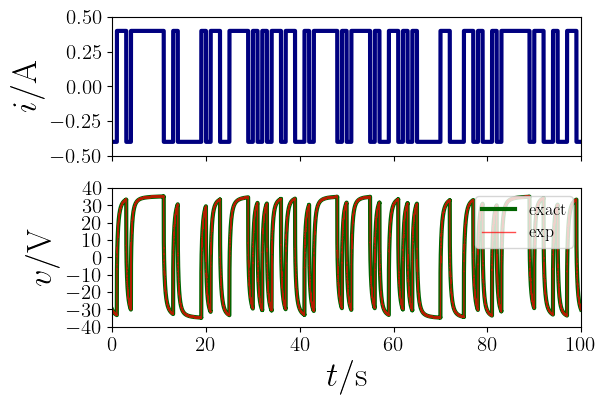

In [9]:
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.44, 6), sharex=True)

# subplot 1: current i(t)
ax1.plot(t, i_t, linewidth=3, color='navy')
ax1.set_ylabel(r'$i/\rm A$', fontsize=25)  # label the y-axis with current in amperes
ax1.set_xlim(0, 100)  
ax1.set_ylim(-0.5, 0.5)
ax1.set_yticks(np.arange(-0.5, 0.51, 0.25))

# subplot 2: voltage responses comparison
ax2.plot(t, v_t_fft, label='exact', linewidth=3, color='darkgreen')
ax2.plot(t, v_t_fft_exp, label='exp', linewidth=1, alpha=0.7, color='red')
ax2.set_xlabel(r'$t/\rm s$', fontsize=25)  # label the x-axis with time in seconds
ax2.set_ylabel(r'$v/\rm V$', fontsize=25)  # label the y-axis with voltage in volts
ax2.set_xlim(0, 100)  
ax2.set_ylim(-40, 40)
ax2.set_yticks(np.arange(-40, 40.1, 10))
ax2.legend(frameon=True, fontsize=12, loc='upper right')  # add legend for clarity

plt.tight_layout()
fig=plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

# 2. Deconvolve the DRT from the time and FFT problems

## 2.1 Define the parameters of the optimization

In [17]:
# Set parameter bounds for Bayesian optimization
pbounds = {
    'log10_lambda_reg': (-8, 2),     # lambda_reg in [1e-6, 1e2]
    'log10_sigma_aristo': (-5, 3),    # sigma_aristo in [1e0, 1e3]
    'log10_alpha': (-8, 3)           # alpha in [1e-6, 1e3]
}

## 2.2 Solve the time problem using Bayesian optimization

In [11]:
# Create a partial function for the Time problem with fixed P and q_np
time_objective = partial(objective_function, P=P_np, q=q_np, gamma_exact=gamma_exact, N_x=N_tau+1)

# Initialize Bayesian optimizer for Time problem
optimizer_time = BayesianOptimization(
    f=time_objective,
    pbounds=pbounds,
    random_state=1,
    verbose=2
)

# Perform the optimization
optimizer_time.maximize(
    init_points=20,  # Number of initial random evaluations of the objective function
    n_iter=100       # Number of iterations of the optimizer
)

# Extract optimal parameters for Time problem
optimal_params_time = optimizer_time.max['params']
optimal_log10_lambda_reg_time = optimal_params_time['log10_lambda_reg']
optimal_log10_sigma_aristo_time = optimal_params_time['log10_sigma_aristo']
optimal_log10_alpha_time = optimal_params_time['log10_alpha']

# Convert optimal parameters back to linear scale
optimal_lambda_reg_time = 10 ** optimal_log10_lambda_reg_time
optimal_sigma_aristo_time = 10 ** optimal_log10_sigma_aristo_time
optimal_alpha_time = 10 ** optimal_log10_alpha_time

# Recompute L2, L, and K with optimal parameters
L2_opt_time = pyDRT.compute_L2_aristo(tau_vec, optimal_sigma_aristo_time)
L_opt_time = np.zeros((L2_opt_time.shape[0], L2_opt_time.shape[1] + 1))
L_opt_time[:, 1:] = L2_opt_time
K_opt_time = L_opt_time.T @ L_opt_time
K_opt_time[0, 0] = optimal_alpha_time

# Recompute gamma_hat with optimal parameters
R_infty_hat_time, gamma_hat_time, x_hat_time = compute_gamma(optimal_lambda_reg_time, P_np, q_np, K_opt_time, N_tau+1)

# Compute minimized error norm
minimized_log10_norm_time = -optimizer_time.max['target']
minimized_norm_time = 10 ** minimized_log10_norm_time

# Output the results for Time problem
print('\nBayesian Optimization Results for Time problem:')
print(f'Optimal lambda_reg: {optimal_lambda_reg_time:.4e}')
print(f'Optimal sigma_aristo: {optimal_sigma_aristo_time:.4e}')
print(f'Optimal alpha: {optimal_alpha_time:.4e}')
print(f'Minimized error norm: {minimized_norm_time:.4e}')

|   iter    |  target   | log10_... | log10_... | log10_... |
-------------------------------------------------------------
| 1         | -0.571279 | -3.829779 | 0.7625959 | -7.998741 |
| 2         | -0.512602 | -4.976674 | -3.825952 | -6.984275 |
| 3         | -0.581326 | -6.137397 | -2.235514 | -3.635557 |
| 4         | -0.802848 | -2.611832 | -1.646443 | -0.462585 |
| 5         | -0.539959 | -5.955477 | 2.0249394 | -7.698736 |
| 6         | -0.964369 | -1.295324 | -1.661561 | -1.854411 |
| 7         | -0.589183 | -6.596130 | -3.415188 | 0.8081902 |
| 8         | -1.518519 | 1.6826157 | -2.492606 | -0.384451 |
| 9         | -1.358055 | 0.7638915 | 2.1568533 | -7.064513 |
| 10        | -0.761693 | -7.609452 | -3.641356 | 1.6595675 |
| 11        | -0.610258 | -7.016531 | -1.631138 | 2.5367848 |
| 12        | -0.791562 | -2.668347 | 0.5350169 | -4.529328 |
| 13        | -0.981221 | -1.134990 | 1.6770053 | -7.798828 |
| 14        | -1.085984 | -0.498556 | 2.9108887 | 0.2298221 |
| 15    

## 2.3 Solve the FFT problem using Bayesian optimization

In [12]:
# Create a partial function for the FFT problem with fixed P_np_fft and q_np_fft
fft_objective = partial(objective_function, P=P_np_fft, q=q_np_fft, gamma_exact=gamma_exact, N_x=N_tau+1)

# Initialize Bayesian optimizer for FFT problem
optimizer_fft = BayesianOptimization(
    f=fft_objective,
    pbounds=pbounds,
    random_state=1,
    verbose=2
)

# Perform the optimization
optimizer_fft.maximize(
    init_points=20,  # Number of initial random evaluations of the objective function
    n_iter=100       # Number of iterations of the optimizer
)

# Extract optimal parameters for FFT problem
optimal_params_fft = optimizer_fft.max['params']
optimal_log10_lambda_reg_fft = optimal_params_fft['log10_lambda_reg']
optimal_log10_sigma_aristo_fft = optimal_params_fft['log10_sigma_aristo']
optimal_log10_alpha_fft = optimal_params_fft['log10_alpha']

# Convert optimal parameters back to linear scale
optimal_lambda_reg_fft = 10 ** optimal_log10_lambda_reg_fft
optimal_sigma_aristo_fft = 10 ** optimal_log10_sigma_aristo_fft
optimal_alpha_fft = 10 ** optimal_log10_alpha_fft

# Recompute L2, L, and K with optimal parameters
L2_opt_fft = pyDRT.compute_L2_aristo(tau_vec, optimal_sigma_aristo_fft)
L_opt_fft = np.zeros((L2_opt_fft.shape[0], L2_opt_fft.shape[1] + 1))
L_opt_fft[:, 1:] = L2_opt_fft
K_opt_fft = L_opt_fft.T @ L_opt_fft
K_opt_fft[0, 0] = optimal_alpha_fft

# Recompute gamma_hat with optimal parameters
R_infty_hat_fft, gamma_hat_fft, x_hat_fft = compute_gamma(optimal_lambda_reg_fft, P_np_fft, q_np_fft, K_opt_fft, N_tau+1)

# Compute minimized error norm
minimized_log10_norm_fft = -optimizer_fft.max['target']
minimized_norm_fft = 10 ** minimized_log10_norm_fft

# Output the results for FFT problem
print('\nBayesian Optimization Results for FFT problem:')
print(f'Optimal lambda_reg: {optimal_lambda_reg_fft:.4e}')
print(f'Optimal sigma_aristo: {optimal_sigma_aristo_fft:.4e}')
print(f'Optimal alpha: {optimal_alpha_fft:.4e}')
print(f'Minimized error norm: {minimized_norm_fft:.4e}')

|   iter    |  target   | log10_... | log10_... | log10_... |
-------------------------------------------------------------
| 1         | -0.544363 | -3.829779 | 0.7625959 | -7.998741 |
| 2         | -0.415399 | -4.976674 | -3.825952 | -6.984275 |
| 3         | -0.527966 | -6.137397 | -2.235514 | -3.635557 |
| 4         | -0.801484 | -2.611832 | -1.646443 | -0.462585 |
| 5         | -0.575223 | -5.955477 | 2.0249394 | -7.698736 |
| 6         | -0.961282 | -1.295324 | -1.661561 | -1.854411 |
| 7         | -0.639273 | -6.596130 | -3.415188 | 0.8081902 |
| 8         | -1.518367 | 1.6826157 | -2.492606 | -0.384451 |
| 9         | -1.357281 | 0.7638915 | 2.1568533 | -7.064513 |
| 10        | -0.722154 | -7.609452 | -3.641356 | 1.6595675 |
| 11        | -0.694354 | -7.016531 | -1.631138 | 2.5367848 |
| 12        | -0.787166 | -2.668347 | 0.5350169 | -4.529328 |
| 13        | -0.979396 | -1.134990 | 1.6770053 | -7.798828 |
| 14        | -1.087221 | -0.498556 | 2.9108887 | 0.2298221 |
| 15    

## 2.4 Plot the exact and recovered DRTs (Figure 3 (a) in the manuscript)

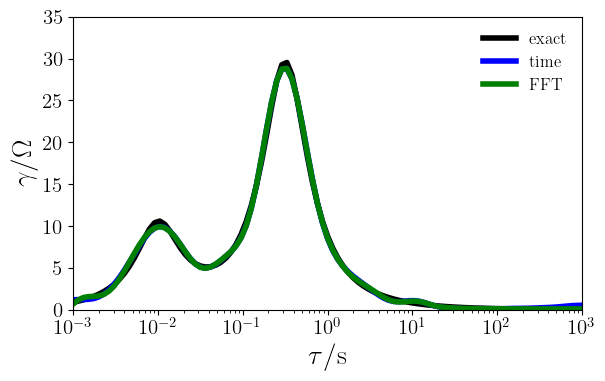

In [13]:
plt.semilogx(tau_vec, gamma_exact, label='exact', linewidth=4, color='black')
plt.semilogx(tau_vec, gamma_hat_time, label='time', linewidth=4, color='blue')
plt.semilogx(tau_vec, gamma_hat_fft, label='FFT', linewidth=4, color='green')
plt.xlim(1E-3, 1E3)
plt.ylim(0, 35)
plt.yticks(np.arange(0, 36, 5))
plt.xlabel(r'$\tau/{\rm s}$', fontsize=20)
plt.ylabel(r'$\gamma/\Omega$', fontsize=20)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
fig=plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

# 3. Reconstruct the impedance

## 3.1 Reconstruct the impedance from the time- and FFT-based DRTs

In [14]:
# define minimum and maximum frequencies
freq = np.fft.fftfreq(N_t, d=dt)
N_fp1 = int(N_t/2)
slice_plus = range(1, N_fp1)
freq_plus = freq[slice_plus]
min_freq = np.min(np.abs(freq_plus))  # should be 0.01 Hz
max_freq = np.max(freq_plus)          # should be approximately 2500 Hz

# calculate log10 of min and max frequencies
log_min_freq = np.log10(min_freq)  # f_min = 0.01 Hz
log_max_freq = np.log10(max_freq)  # f_max ≈ 2499.99 Hz

# number of decades
num_decades = log_max_freq - log_min_freq

# number of frequency points (10 per decade)
N_freq = int(10 * num_decades) + 1

# create logarithmically spaced frequency vector
freq_log = np.logspace(log_min_freq, log_max_freq, N_freq)

# compute A_re_log and A_im_log using freq_log and tau_vec
A_re_log = pyDRT.compute_A_re(freq_log, tau_vec)
A_im_log = pyDRT.compute_A_im(freq_log, tau_vec)

# create A_R_inf_log similar to A_R_inf in the original A matrix
A_R_inf_log = np.zeros((2 * N_freq, 1))
A_R_inf_log[0:N_freq, 0] = 1.0  # setting R_inf for the first N_freq points

# stack A_re_log and A_im_log vertically
A_log_stack = np.vstack((A_re_log, A_im_log))

# concatenate A_R_inf_log with the stacked A_re_log and A_im_log to form A_log
A_log = np.hstack((A_R_inf_log, A_log_stack))

# compute exact impedance at freq_log
Z_exact_log = R_inf + R_ct_1/(1.0+(1j*2.0*pi*tau_1*freq_log)**phi_1) +\
                        R_ct_2/(1.0+(1j*2.0*pi*tau_2*freq_log)**phi_2)

# compute Z_log in real and imaginary parts
Z_log_time_re_im = A_log @ x_hat_time

# separate real and imaginary parts
Z_log_time_real = Z_log_time_re_im[0:N_freq]
Z_log_time_imag = Z_log_time_re_im[N_freq:]

# combine to form the complex impedance
Z_log_time = Z_log_time_real + 1j * Z_log_time_imag

# Compute Z_log in real and imaginary parts using the same A_log
Z_log_fft_re_im = A_log@x_hat_fft

# Separate real and imaginary parts
Z_log_fft_real = Z_log_fft_re_im[0:N_freq]
Z_log_fft_imag = Z_log_fft_re_im[N_freq:]

# Combine to form the complex impedance
Z_log_fft = Z_log_fft_real + 1j * Z_log_fft_imag

## 3.2 Nyquist plots of the exact and recovered impedances (Figure 1 (c) in the manuscript)

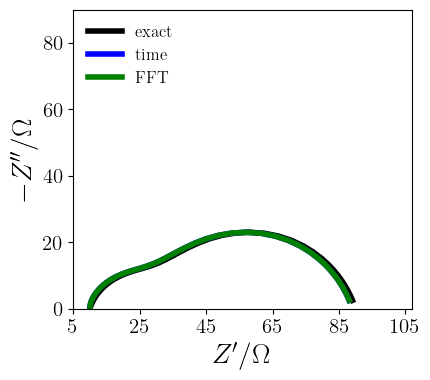

In [15]:
plt.plot(Z_exact_log.real, -Z_exact_log.imag, linewidth=4, color='black', label='exact')
plt.plot(Z_log_time.real, -Z_log_time.imag, 'blue', linewidth=4, label='time')
plt.plot(Z_log_fft.real, -Z_log_fft.imag, 'green', linewidth=4, label='FFT')
plt.axis('scaled')
plt.xlabel(r'$Z^\prime/\Omega$', fontsize=20)
plt.ylabel(r'$-Z^{\prime\prime}/\Omega$', fontsize=20)
plt.legend(frameon=False, fontsize=12, loc='upper left')
plt.xlim(5, 107)
plt.ylim(0, 90)
plt.xticks(np.arange(5, 107.1, 20))
plt.yticks(np.arange(0, 90.1, 20))
plt.tight_layout()
fig=plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.3 Bode plots of the exact and recovered impedances (Figure 3 (c) in the manuscript)

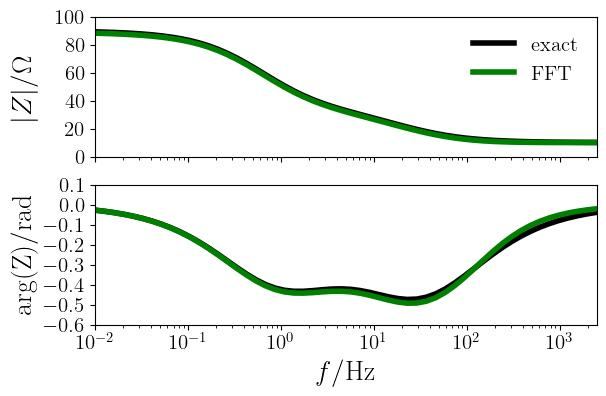

In [16]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.semilogx(freq_log, np.abs(Z_exact_log), linewidth=4, color='black', label='exact')
ax1.semilogx(freq_log, np.abs(Z_log_fft), linewidth=4, color='green', label='FFT')
ax1.set_ylabel(r'$|Z|/\mathrm{\Omega}$', fontsize = 20)
ax1.set_xlim(np.min(freq_log), np.max(freq_log))
ax1.set_ylim(0, 100)
ax1.set_yticks(np.arange(0, 100.1, step=20)) 
ax1.legend(frameon=False, fontsize = 15)

ax2.semilogx(freq_log, np.angle(Z_exact_log), linewidth=4, color='black', label='exact')
ax2.semilogx(freq_log, np.angle(Z_log_fft), linewidth=4, color='green', label='FFT')
ax2.set_ylabel(r'$\rm arg(Z)/\rm rad$', fontsize = 20)
ax2.set_ylim(-0.6, 0.1)
ax2.set_yticks(np.arange(-0.6, 0.11, 0.1))

plt.xlabel(r'$f/{\rm Hz}$', fontsize = 20)
fig.align_ylabels()
fig.set_size_inches(6.472, 4)
plt.show()